In [1]:
from sklift.datasets import fetch_lenta
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

from catboost import CatBoostClassifier, Pool
import shap

from causalml.metrics import plot_gain, auuc_score
from causalml.inference.tree import UpliftTreeClassifier, UpliftRandomForestClassifier
from causalml.inference.meta import BaseDRClassifier, BaseRClassifier, BaseSClassifier, BaseTClassifier, BaseXClassifier
from causalml.inference.iv import BaseDRIVRegressor
import optuna

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import auc
from IPython.display import clear_output

import warnings
warnings.filterwarnings('ignore')

/Users/kolpakovaksenia/diploma/.dvenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Failed to import duecredit due to No module named 'duecredit'


In [2]:
import sys
print(sys.executable)

/Users/kolpakovaksenia/diploma/.dvenv/bin/python


In [3]:
SEED = 42

In [4]:
BASE_MODEL = CatBoostClassifier(
    loss_function='Logloss',
    verbose=False,
    random_state=SEED
  )

In [5]:
dataset = fetch_lenta()
data, target, treatment = dataset.data, dataset.target, dataset.treatment

In [6]:
# Преобразование признака gender
data['gender'] = data['gender'].map({'Male': 1, 'Female': 0})
data['gender'] = data['gender'].fillna(-1)

In [7]:
# Заполнение пропусков
data = data.fillna(-100)

In [8]:
# Удаление явных дубликатов
data = data.drop_duplicates()

In [9]:
# Разбиение на train, valid, test выборки

data['treatment'] = treatment
data['treatment'] = (data['treatment'] == 'test').astype(int)
data['target'] = target

train_val_idx, test_idx = train_test_split(data.index, test_size=0.2, random_state=SEED, stratify=data[['treatment', 'target']])

train_idx, val_idx = train_test_split(train_val_idx, test_size=0.25, random_state=SEED, stratify=data.loc[train_val_idx, ['treatment', 'target']])

X_train = data.drop(columns=['treatment', 'target']).loc[train_idx]
X_val = data.drop(columns=['treatment', 'target']).loc[val_idx]
X_test = data.drop(columns=['treatment', 'target']).loc[test_idx]

treatment_train = data['treatment'][train_idx]
treatment_val = data['treatment'][val_idx]
treatment_test = data['treatment'][test_idx]

y_train = target[train_idx]
y_val = target[val_idx]
y_test = target[test_idx]

In [10]:
def get_uplift(model_t, model_c, X, treatment, y, selected_features):

  X_selected = X[selected_features]

  pred_c = model_c.predict_proba(X_selected)[:, 1]
  pred_t = model_t.predict_proba(X_selected)[:, 1]

  uplift_pred = pred_t - pred_c

  pred_data = pd.DataFrame({'uplift': uplift_pred,
                            'y': y,
                            'treatment': treatment})

  auuc = auuc_score(pred_data, outcome_col='y', treatment_col='treatment')
  # auuc = plot_auuc_curve(y, treatment, uplift_pred, draw_auuc=draw_auuc)

  print('AUUC:', auuc.squeeze())

  return uplift_pred, auuc

In [11]:
def train_tlearner(base_model, X_train, treatment_train, y_train,
                   X_val, treatment_val, y_val,
                   selected_features, n_trials=50):

    X_train = pd.concat([X_train, treatment_train], axis=1)
    y_train = pd.concat([y_train, treatment_train], axis=1)

    base_params = {
        'loss_function': 'Logloss',
        'verbose': False,
        'random_state': SEED
    }

    def objective(trial):

        params_c = {
            'depth': trial.suggest_int('depth_c', 4, 10),
            'learning_rate': trial.suggest_float('learning_rate_c', 0.01, 0.3, log=True),
            'iterations': trial.suggest_int('iterations_c', 300, 1500),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg_c', 1, 20),
            'bagging_temperature': trial.suggest_float('bagging_temperature_c', 0, 10),
            'random_strength': trial.suggest_float('random_strength_c', 0, 10),
            'min_data_in_leaf': trial.suggest_int('min_data_in_leaf_c', 1, 100),
        }

        params_t = {
            'depth': trial.suggest_int('depth_t', 4, 10),
            'learning_rate': trial.suggest_float('learning_rate_t', 0.01, 0.3, log=True),
            'iterations': trial.suggest_int('iterations_t', 300, 1500),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg_t', 1, 20),
            'bagging_temperature': trial.suggest_float('bagging_temperature_t', 0, 10),
            'random_strength': trial.suggest_float('random_strength_t', 0, 10),
            'min_data_in_leaf': trial.suggest_int('min_data_in_leaf_t', 1, 100),
        }

        X_c = X_train[treatment_train == 0][selected_features]
        y_c = y_train[treatment_train == 0]['response_att']

        X_t = X_train[treatment_train == 1][selected_features]
        y_t = y_train[treatment_train == 1]['response_att']

        model_c = base_model.__class__(**{**params_c, **base_params})
        model_c.fit(X_c, y_c)

        model_t = base_model.__class__(**{**params_t, **base_params})
        model_t.fit(X_t, y_t)

        _, auuc_val = get_uplift(
            model_t,
            model_c,
            X_val,
            treatment_val,
            y_val,
            selected_features
        )

        return auuc_val.item()


    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, n_jobs=-1)

    best_params = study.best_params

    params_c = {
        'depth': best_params['depth_c'],
        'learning_rate': best_params['learning_rate_c'],
        'iterations': best_params['iterations_c'],
        'l2_leaf_reg': best_params['l2_leaf_reg_c'],
        'bagging_temperature': best_params['bagging_temperature_c'],
        'random_strength': best_params['random_strength_c'],
        'min_data_in_leaf': best_params['min_data_in_leaf_c'],
    }

    params_t = {
        'depth': best_params['depth_t'],
        'learning_rate': best_params['learning_rate_t'],
        'iterations': best_params['iterations_t'],
        'l2_leaf_reg': best_params['l2_leaf_reg_t'],
        'bagging_temperature': best_params['bagging_temperature_t'],
        'random_strength': best_params['random_strength_t'],
        'min_data_in_leaf': best_params['min_data_in_leaf_t'],
    }

    X_c = X_train[treatment_train == 0][selected_features]
    y_c = y_train[treatment_train == 0]['response_att']

    X_t = X_train[treatment_train == 1][selected_features]
    y_t = y_train[treatment_train == 1]['response_att']

    model_c = base_model.__class__(**{**params_c, **base_params})
    model_c.fit(X_c, y_c)

    model_t = base_model.__class__(**{**params_t, **base_params})
    model_t.fit(X_t, y_t)

    uplift_pred_train, auuc_train = get_uplift(
        model_t,
        model_c,
        X_train,
        treatment_train,
        y_train['response_att'],
        selected_features
    )

    return model_t, model_c, uplift_pred_train, auuc_train, study

### Customer feature selection from high‐dimensional bank direct marketing data for uplift modeling.

Авторы данной статьи предлагают двухстадийный подход к отбору фичей:

1. Первый этап - выделение релевантных признаков с помощью Bin-based Divergence Filters. (Из статьи Feature Selection Methods for Uplift Modeling and Heterogeneous Treatment Effect). К уже сущесствующим методам авторы предлагают еще два -
    1. UC filter - данные разбиваются на K Бинов на основе перцентилей значений признака. Для каждого Бина вычисляются - сумма значений целевой переменной в treatment группе для данного бина (фактически, количество положительных исходов в treatment); сумма значений целевой переменной в control группе для данного бина; количество наблюдений в treatment группе в данном бине;  количество наблюдений в control группе в данном бине. Итоговый score для признака F вычисляется как сумма uplift'ов по всем бинам, взвешенная на долю наблюдений в каждом бине. Высокое значение RSUC говорит о том, что признак хорошо разделяет данные на группы с разным uplift'ом. Такой признак потенциально важен для моделирования гетерогенности эффекта воздействия (CATE).
    2. AUUC filter использует параметрическую uplift-кривую для оценки важности признаков. Все наблюдения сортируются по возрастанию значения признака F. Для каждого t (количество первых наблюдений в отсортированном списке) строится точка на кривой. Функция кривой задается следующим образом: f(F_j, t) = (Y_t^T / N_t^T - Y_t^C / N_t^C) * (N_t^T + N_t^C), где Y_t^T - сумма исходов в treatment группе среди первых t наблюдений, N_t^T - количество наблюдений в treatment группе среди первых t наблюдений, Y_t^C - 	сумма исходов в control группе среди первых t наблюдений, N_t^C - количество наблюдений в control группе среди первых t наблюдений. Итоговый score для признака F - это площадь под построенной кривой. Высокое значение метрики говорит о том, что при сортировке по данному признаку, объекты с высокими значениями признака имеют систематически другой uplift, чем объекты с низкими значениями. Такой признак потенциально является хорошим модификатором эффекта воздействия.
2. Второй этап - анализ избыточности на отобранном наборе признаков. Начиная с первого по значимости признака в релевантном наборе, мы удаляем признаки с более низким рангом, коэффициент корреляции которых с ним превышает заданный параметр 𝜌₀. В данной работе параметр 𝜌₀ установлен равным 0.8.

Из библиотеки upliftml возьмем метод UpliftCurveFilter, он соотвествует второму предложенному в статье методу оценки признаков с помощью uplift-кривой:

In [12]:
import numpy as np
import pandas as pd
from sklearn.metrics import auc

def rsaauuc_single_feature(
    x: pd.Series,
    treatment: pd.Series,
    y: pd.Series,
    n_bins=10
):
    df = pd.DataFrame({
        'x': x,
        'treatment': treatment,
        'y': y
    }).dropna()

    if df['x'].nunique() < 3:
        return 0.0

    try:
        df = df.sort_values('x')
        df['bin'] = pd.qcut(df['x'], q=n_bins, duplicates='drop')
    except ValueError:
        return 0.0

    uplift_values = []

    for _, group in df.groupby('bin', observed=True):
        yt = group.loc[group.treatment == 1, 'y']
        yc = group.loc[group.treatment == 0, 'y']

        if len(yt) < 5 or len(yc) < 5:
            continue

        uplift_values.append(yt.mean() - yc.mean())

    if len(uplift_values) < 2:
        return 0.0

    return auc(np.arange(len(uplift_values)), uplift_values)

In [13]:
from tqdm import tqdm


def rsaauuc_feature_ranking(
    X: pd.DataFrame,
    treatment: pd.Series,
    y: pd.Series,
    n_bins=10
):
    scores = {}

    for col in tqdm(X.columns):
        scores[col] = rsaauuc_single_feature(
            X[col], treatment, y, n_bins=n_bins
        )

    return (
        pd.Series(scores)
        .sort_values(ascending=False)
    )

In [14]:
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform


def redundancy_reduction(
    X: pd.DataFrame,
    scores: pd.Series,
    top_k=80,
    corr_threshold=0.85
):
    top_feats = scores.head(top_k).index.tolist()

    corr = X[top_feats].corr().abs()

    dist = 1 - corr
    condensed = squareform(dist.values)

    Z = linkage(condensed, method='average')

    clusters = fcluster(Z, t=1 - corr_threshold, criterion='distance')

    cluster_df = pd.DataFrame({
        'feature': top_feats,
        'cluster': clusters,
        'score': scores.loc[top_feats].values
    })

    selected = (
        cluster_df
        .sort_values('score', ascending=False)
        .groupby('cluster')
        .head(1)['feature']
        .tolist()
    )

    return selected, cluster_df

In [15]:
def get_features(
    X, treatment, y,
    n_bins=10,
    top_k=80,
    corr_threshold=0.80
):
    scores = rsaauuc_feature_ranking(
        X, treatment, y, n_bins=n_bins
    )

    selected, cluster_df = redundancy_reduction(
        X, scores,
        top_k=top_k,
        corr_threshold=corr_threshold
    )

    return selected, scores, cluster_df

In [16]:
 selected_features_v1, scores_v1, cluster_df_v1 = get_features(X_train, treatment_train, y_train)

100%|█████████████████████████████████████████| 193/193 [00:06<00:00, 31.10it/s]


In [17]:
len(selected_features_v1)

48

In [18]:
model_t_v1, model_c_v1, uplift_pred_train_v1, auuc_train_v1, study_v1 = train_tlearner(BASE_MODEL, X_train, treatment_train, y_train,
                                                                             X_val, treatment_val, y_val,
                                                                             selected_features_v1)

[I 2026-03-23 23:02:01,570] A new study created in memory with name: no-name-dab72713-885d-4278-bafe-820864612e32
[I 2026-03-23 23:02:50,381] Trial 11 finished with value: 0.45923068446840953 and parameters: {'depth_c': 6, 'learning_rate_c': 0.08016358801891216, 'iterations_c': 431, 'l2_leaf_reg_c': 19.459726423007687, 'bagging_temperature_c': 2.2871445351474753, 'random_strength_c': 9.007662770289276, 'min_data_in_leaf_c': 49, 'depth_t': 4, 'learning_rate_t': 0.021715443961629985, 'iterations_t': 458, 'l2_leaf_reg_t': 19.7821161290554, 'bagging_temperature_t': 6.730239446147801, 'random_strength_t': 8.790710943446943, 'min_data_in_leaf_t': 83}. Best is trial 11 with value: 0.45923068446840953.


AUUC: 0.45923068446840953


[I 2026-03-23 23:03:11,511] Trial 9 finished with value: 0.6563629069225271 and parameters: {'depth_c': 8, 'learning_rate_c': 0.031008362268312644, 'iterations_c': 548, 'l2_leaf_reg_c': 3.363542113927668, 'bagging_temperature_c': 6.4958385804075816, 'random_strength_c': 6.549231823055411, 'min_data_in_leaf_c': 54, 'depth_t': 5, 'learning_rate_t': 0.12540745557286176, 'iterations_t': 495, 'l2_leaf_reg_t': 2.3336189518475803, 'bagging_temperature_t': 5.658010528900382, 'random_strength_t': 4.179821394709001, 'min_data_in_leaf_t': 31}. Best is trial 9 with value: 0.6563629069225271.


AUUC: 0.6563629069225271


[I 2026-03-23 23:03:26,285] Trial 2 finished with value: 0.5710892827301793 and parameters: {'depth_c': 5, 'learning_rate_c': 0.2914850395179318, 'iterations_c': 920, 'l2_leaf_reg_c': 6.363239414908463, 'bagging_temperature_c': 7.672227569475377, 'random_strength_c': 8.963517698038972, 'min_data_in_leaf_c': 77, 'depth_t': 4, 'learning_rate_t': 0.04479800225022585, 'iterations_t': 747, 'l2_leaf_reg_t': 14.4214607336701, 'bagging_temperature_t': 4.498580236838791, 'random_strength_t': 0.7959533666176011, 'min_data_in_leaf_t': 41}. Best is trial 9 with value: 0.6563629069225271.


...

AUUC: 0.7727262965194822


[I 2026-03-23 23:15:05,083] Trial 48 finished with value: 0.7251517968977738 and parameters: {'depth_c': 5, 'learning_rate_c': 0.18683753779445425, 'iterations_c': 1366, 'l2_leaf_reg_c': 17.193357533334485, 'bagging_temperature_c': 6.711364249547083, 'random_strength_c': 9.800999352737941, 'min_data_in_leaf_c': 26, 'depth_t': 9, 'learning_rate_t': 0.15854416206234825, 'iterations_t': 1135, 'l2_leaf_reg_t': 9.072903274752992, 'bagging_temperature_t': 8.34874953894902, 'random_strength_t': 5.570380359345567, 'min_data_in_leaf_t': 89}. Best is trial 47 with value: 0.7727262965194822.


AUUC: 0.7251517968977738


[I 2026-03-23 23:15:11,097] Trial 49 finished with value: 0.600314039293653 and parameters: {'depth_c': 5, 'learning_rate_c': 0.17050747526050533, 'iterations_c': 1368, 'l2_leaf_reg_c': 17.101885465112108, 'bagging_temperature_c': 8.416662968017672, 'random_strength_c': 9.966688879890562, 'min_data_in_leaf_c': 25, 'depth_t': 9, 'learning_rate_t': 0.15037872949744202, 'iterations_t': 1147, 'l2_leaf_reg_t': 18.032800089802645, 'bagging_temperature_t': 8.574742467095799, 'random_strength_t': 3.3539085913475666, 'min_data_in_leaf_t': 90}. Best is trial 47 with value: 0.7727262965194822.


AUUC: 0.600314039293653
AUUC: 9.392380429611073


In [19]:
uplift_pred_test_v1, auuc_test_v1 = get_uplift(model_t_v1, model_c_v1, X_test, treatment_test, y_test, selected_features_v1)

AUUC: 0.47410289031925357


In [20]:
# 0.5764277840921775 - до оптуны

### Doubly Robust Adaptive LASSO for Effect

In [21]:
from catboost import CatBoostRegressor, CatBoostClassifier


def train_nuisance_models(X, T, y):
    mu1 = CatBoostRegressor(verbose=False, random_state=SEED)
    mu0 = CatBoostRegressor(verbose=False, random_state=SEED)
    e = CatBoostClassifier(verbose=False, random_state=SEED)

    mu1.fit(X[T==1], y[T==1])
    mu0.fit(X[T==0], y[T==0])
    e.fit(X, T)

    return mu1, mu0, e

In [22]:
def compute_dr_pseudo_outcome(X, T, y, mu1, mu0, e):
    mu1_pred = mu1.predict(X)
    mu0_pred = mu0.predict(X)
    e_pred = np.clip(e.predict_proba(X)[:,1], 1e-3, 1-1e-3)

    tau_hat = (
        T * (y - mu1_pred) / e_pred
        - (1-T) * (y - mu0_pred) / (1 - e_pred)
        + mu1_pred - mu0_pred
    )

    return tau_hat

In [23]:
from sklearn.linear_model import Ridge

def initial_ridge_weights(X, tau_hat):
    ridge = Ridge(alpha=1.0, random_state=SEED)
    ridge.fit(X, tau_hat)
    return np.abs(ridge.coef_)

In [24]:
from sklearn.linear_model import Lasso

def adaptive_lasso(X, tau_hat, weights, alpha=0.01):
    X_scaled = X / (weights + 1e-6)

    lasso = Lasso(alpha=alpha, random_state=SEED)
    lasso.fit(X_scaled, tau_hat)

    beta = lasso.coef_ / (weights + 1e-6)

    return beta


In [25]:
def dr_adaptive_lasso_feature_selection(
    X, T, y,
    alpha=0.01
):
    mu1, mu0, e = train_nuisance_models(X, T, y)

    tau_hat = compute_dr_pseudo_outcome(X, T, y, mu1, mu0, e)

    weights = initial_ridge_weights(X, tau_hat)

    beta = adaptive_lasso(X, tau_hat, weights, alpha)

    selected_features = X.columns[np.abs(beta) > 1e-6].tolist()

    return selected_features, beta, tau_hat


In [26]:
selected_features_v2, beta, tau_hat = dr_adaptive_lasso_feature_selection(X_train, treatment_train, y_train, alpha=0.001)

In [27]:
len(selected_features_v2)

184

In [28]:
model_t_v2, model_c_v2, uplift_pred_train_v2, auuc_train_v2, study_v2 = train_tlearner(BASE_MODEL, 
                                                                                       X_train, 
                                                                                       treatment_train, 
                                                                                       y_train, 
                                                                                       X_val, 
                                                                                       treatment_val, 
                                                                                       y_val, 
                                                                                       selected_features_v2)

[I 2026-03-23 23:17:06,606] A new study created in memory with name: no-name-f52c1bc3-dd70-4373-9c57-fd976f7b410f
[I 2026-03-23 23:19:34,425] Trial 11 finished with value: 0.643221365315951 and parameters: {'depth_c': 4, 'learning_rate_c': 0.0918801607464502, 'iterations_c': 440, 'l2_leaf_reg_c': 12.385818057788594, 'bagging_temperature_c': 3.002573332473509, 'random_strength_c': 8.01250375568198, 'min_data_in_leaf_c': 77, 'depth_t': 6, 'learning_rate_t': 0.23439752163217661, 'iterations_t': 462, 'l2_leaf_reg_t': 16.033806068740006, 'bagging_temperature_t': 1.8170369814821774, 'random_strength_t': 5.38251220551507, 'min_data_in_leaf_t': 85}. Best is trial 11 with value: 0.643221365315951.


AUUC: 0.643221365315951


[I 2026-03-23 23:20:49,733] Trial 8 finished with value: 0.6320365312437302 and parameters: {'depth_c': 5, 'learning_rate_c': 0.011870449450535787, 'iterations_c': 507, 'l2_leaf_reg_c': 16.46089786388642, 'bagging_temperature_c': 2.657023724233264, 'random_strength_c': 3.362888342582538, 'min_data_in_leaf_c': 4, 'depth_t': 6, 'learning_rate_t': 0.032441157909754985, 'iterations_t': 691, 'l2_leaf_reg_t': 9.456261133323089, 'bagging_temperature_t': 2.9898985623062844, 'random_strength_t': 5.2467572064314965, 'min_data_in_leaf_t': 59}. Best is trial 11 with value: 0.643221365315951.


AUUC: 0.6320365312437302


[I 2026-03-23 23:20:57,086] Trial 1 finished with value: 0.5630173976516829 and parameters: {'depth_c': 6, 'learning_rate_c': 0.20605842429325227, 'iterations_c': 435, 'l2_leaf_reg_c': 4.166751422278015, 'bagging_temperature_c': 3.475978965904666, 'random_strength_c': 8.126101016886299, 'min_data_in_leaf_c': 74, 'depth_t': 4, 'learning_rate_t': 0.13933859501088286, 'iterations_t': 914, 'l2_leaf_reg_t': 11.932402967924888, 'bagging_temperature_t': 0.9385905170829933, 'random_strength_t': 3.145412024151073, 'min_data_in_leaf_t': 5}. Best is trial 11 with value: 0.643221365315951.


...

AUUC: 0.6886069648447523


[I 2026-03-23 23:51:32,146] Trial 48 finished with value: 0.5652442992680946 and parameters: {'depth_c': 6, 'learning_rate_c': 0.03544423403999024, 'iterations_c': 1316, 'l2_leaf_reg_c': 14.197750215709673, 'bagging_temperature_c': 0.4329401995054747, 'random_strength_c': 7.312929898840323, 'min_data_in_leaf_c': 83, 'depth_t': 6, 'learning_rate_t': 0.05122861445834026, 'iterations_t': 1064, 'l2_leaf_reg_t': 1.3350323403557776, 'bagging_temperature_t': 4.663611459426485, 'random_strength_t': 3.0396355449835113, 'min_data_in_leaf_t': 50}. Best is trial 37 with value: 0.7908898200507362.


AUUC: 0.5652442992680946


[I 2026-03-23 23:51:35,620] Trial 49 finished with value: 0.6487773133009614 and parameters: {'depth_c': 6, 'learning_rate_c': 0.0321688528357597, 'iterations_c': 1344, 'l2_leaf_reg_c': 14.154748411651969, 'bagging_temperature_c': 6.43021939061341, 'random_strength_c': 4.400376050301804, 'min_data_in_leaf_c': 84, 'depth_t': 6, 'learning_rate_t': 0.04849581200620444, 'iterations_t': 999, 'l2_leaf_reg_t': 1.1618235234361736, 'bagging_temperature_t': 4.708630143957194, 'random_strength_t': 3.1458739518581056, 'min_data_in_leaf_t': 49}. Best is trial 37 with value: 0.7908898200507362.


AUUC: 0.6487773133009614
AUUC: 6.733358606653238


In [29]:
uplift_pred_test_v2, auuc_test_v2 = get_uplift(model_t_v2, model_c_v2, X_test, treatment_test, y_test, 
                                               selected_features_v2)

AUUC: 0.6255061155390529


In [30]:
# до оптуны метрика была выше - 0.6668880309490919

### A Non-parametric Bayesian Approach for Uplift Discretization and Feature Selection

Код реализован в библиотеке kuplift - https://github.com/UData-Orange/kuplift/blob/main/kuplift/feature_selection.py

Для ускорения работы отберем признаки на валидационной выборке

In [31]:
import kuplift as kp

In [32]:
fs = kp.FeatureSelection()

important_vars = fs.filter(
    X_val,
    treatment_val,
    y_val
)

In [33]:
important_vars

{'gender': 0,
 'promo_share_15d': 3.485882970737384e-05,
 'k_var_sku_price_1m_g26': 3.969220190779956e-05,
 'k_var_sku_price_3m_g24': 3.973858593423515e-05,
 'mean_discount_depth_15d': 4.0548634555479084e-05,
 'sale_sum_12m_g26': 4.297170548488893e-05,
 'k_var_sku_price_1m_g54': 4.331536845124712e-05,
 'disc_sum_6m_g34': 4.3543643487371094e-05,
 'k_var_sku_price_3m_g33': 4.428677536220568e-05,
 'k_var_disc_share_1m_g49': 4.5032289431259245e-05,
 'k_var_count_per_cheque_3m_g24': 4.582397830270521e-05,
 'sale_sum_3m_g33': 4.59610954334403e-05,
 'k_var_count_per_cheque_6m_g24': 4.604826990506511e-05,
 'k_var_sku_price_1m_g40': 4.730351463399946e-05,
 'k_var_count_per_cheque_15d_g34': 4.7396768259551914e-05,
 'k_var_sku_price_6m_g41': 4.7548803476762865e-05,
 'sale_count_6m_g32': 4.755212611006628e-05,
 'k_var_sku_price_3m_g54': 4.779033158926403e-05,
 'k_var_sku_price_3m_g32': 4.80703186608137e-05,
 'k_var_cheque_15d': 4.8244707873699545e-05,
 'k_var_sku_price_1m_g49': 4.854045578555415e-

In [34]:
len(important_vars)

193

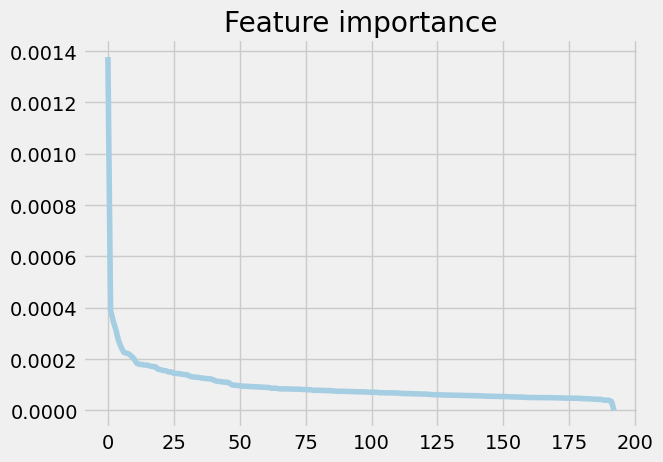

In [35]:
scores = sorted(important_vars.values(), reverse=True)

plt.plot(scores)
plt.title('Feature importance')
plt.show()

In [36]:
def find_elbow(scores_dict):
    scores = np.array(sorted(scores_dict.values(), reverse=True))

    x = np.arange(len(scores))
    y = scores

    line_start = np.array([0, y[0]])
    line_end = np.array([len(scores)-1, y[-1]])

    line_vec = line_end - line_start
    line_vec_norm = line_vec / np.linalg.norm(line_vec)

    distances = []
    for i in range(len(scores)):
        point = np.array([i, y[i]])
        vec = point - line_start
        proj = np.dot(vec, line_vec_norm) * line_vec_norm
        dist = np.linalg.norm(vec - proj)
        distances.append(dist)

    elbow_idx = np.argmax(distances)
    return elbow_idx + 1

optimal_features = find_elbow(important_vars)
print(f'Оптимальное количество признаков по локтю: {optimal_features}')

Оптимальное количество признаков по локтю: 12


In [37]:
scores_series = pd.Series(important_vars).sort_values(ascending=False)
top_features = scores_series.head(optimal_features).index.tolist()

In [38]:
top_features

['perdelta_days_between_visits_15_30d',
 'cheque_count_6m_g25',
 'k_var_cheque_group_width_15d',
 'k_var_days_between_visits_15d',
 'sale_count_12m_g49',
 'cheque_count_6m_g32',
 'sale_count_12m_g54',
 'response_sms',
 'cheque_count_6m_g20',
 'cheque_count_12m_g57',
 'k_var_count_per_cheque_6m_g44',
 'crazy_purchases_cheque_count_12m']

In [39]:
model_t_v3, model_c_v3, uplift_pred_train_v3, auuc_train_v3, study = train_tlearner(BASE_MODEL, X_train, treatment_train, y_train, 
                                                                             X_val, treatment_val, y_val, 
                                                                             top_features)

[I 2026-03-24 00:20:01,807] A new study created in memory with name: no-name-db379a23-3061-4bf3-8c95-0225607a7263
[I 2026-03-24 00:20:52,919] Trial 2 finished with value: 0.3901797970057982 and parameters: {'depth_c': 4, 'learning_rate_c': 0.024576549493920363, 'iterations_c': 1013, 'l2_leaf_reg_c': 12.151921232812686, 'bagging_temperature_c': 3.465097628959959, 'random_strength_c': 5.577125194740535, 'min_data_in_leaf_c': 40, 'depth_t': 8, 'learning_rate_t': 0.24245851645452957, 'iterations_t': 450, 'l2_leaf_reg_t': 5.3716483651592455, 'bagging_temperature_t': 0.23691271898532928, 'random_strength_t': 7.169875491568119, 'min_data_in_leaf_t': 26}. Best is trial 2 with value: 0.3901797970057982.


AUUC: 0.3901797970057982


[I 2026-03-24 00:21:02,664] Trial 7 finished with value: 0.45865300197745873 and parameters: {'depth_c': 8, 'learning_rate_c': 0.019341109959086673, 'iterations_c': 1367, 'l2_leaf_reg_c': 11.826014721349274, 'bagging_temperature_c': 9.328571288665856, 'random_strength_c': 9.239328416794343, 'min_data_in_leaf_c': 88, 'depth_t': 6, 'learning_rate_t': 0.24211180322128198, 'iterations_t': 372, 'l2_leaf_reg_t': 4.58405810311445, 'bagging_temperature_t': 0.8303195333701396, 'random_strength_t': 1.7977637700163784, 'min_data_in_leaf_t': 20}. Best is trial 7 with value: 0.45865300197745873.


AUUC: 0.45865300197745873


[I 2026-03-24 00:21:05,693] Trial 10 finished with value: 0.6150655593593077 and parameters: {'depth_c': 6, 'learning_rate_c': 0.07112069182931754, 'iterations_c': 1041, 'l2_leaf_reg_c': 11.073681640028221, 'bagging_temperature_c': 9.189542258648586, 'random_strength_c': 8.4008588986842, 'min_data_in_leaf_c': 34, 'depth_t': 4, 'learning_rate_t': 0.23138319147791064, 'iterations_t': 718, 'l2_leaf_reg_t': 16.52860244547325, 'bagging_temperature_t': 1.5015590868031259, 'random_strength_t': 4.365947889921586, 'min_data_in_leaf_t': 60}. Best is trial 10 with value: 0.6150655593593077.


...

AUUC: 0.5222848000233008


[I 2026-03-24 00:27:48,514] Trial 48 finished with value: 0.5667214261077659 and parameters: {'depth_c': 4, 'learning_rate_c': 0.099205222416944, 'iterations_c': 972, 'l2_leaf_reg_c': 16.87413193878096, 'bagging_temperature_c': 2.0921412678879894, 'random_strength_c': 1.7146814268169042, 'min_data_in_leaf_c': 52, 'depth_t': 8, 'learning_rate_t': 0.01739998380168734, 'iterations_t': 1256, 'l2_leaf_reg_t': 15.136433465179264, 'bagging_temperature_t': 0.4458810596015065, 'random_strength_t': 7.990718142931992, 'min_data_in_leaf_t': 51}. Best is trial 40 with value: 0.7444283303179166.


AUUC: 0.5667214261077659


[I 2026-03-24 00:27:50,086] Trial 49 finished with value: 0.5502870273582747 and parameters: {'depth_c': 4, 'learning_rate_c': 0.08521541405535694, 'iterations_c': 909, 'l2_leaf_reg_c': 16.759284848796497, 'bagging_temperature_c': 2.2982725523628527, 'random_strength_c': 1.4438396125157582, 'min_data_in_leaf_c': 55, 'depth_t': 8, 'learning_rate_t': 0.015694883800645407, 'iterations_t': 1232, 'l2_leaf_reg_t': 14.042514442223089, 'bagging_temperature_t': 5.301444258119078, 'random_strength_t': 5.455004648598461, 'min_data_in_leaf_t': 46}. Best is trial 40 with value: 0.7444283303179166.


AUUC: 0.5502870273582747
AUUC: 3.3909888212566264


In [40]:
uplift_pred_test_v3, auuc_test_v3 = get_uplift(model_t_v3, model_c_v3, X_test, treatment_test, y_test, top_features)

AUUC: 0.49456822999954864


In [41]:
# попробуем взять топ-50 фичей
top_features_v2 = scores_series.head(50).index.tolist()
model_t_v4, model_c_v4, uplift_pred_train_v4, auuc_train_v4, study = train_tlearner(BASE_MODEL, X_train, treatment_train, y_train, 
                                                                             X_val, treatment_val, y_val, 
                                                                             top_features_v2)

[I 2026-03-24 00:28:05,280] A new study created in memory with name: no-name-5a6ace4c-d92e-44f5-b8f5-f5a4e149371d
[I 2026-03-24 00:30:19,921] Trial 11 finished with value: 0.69938189065373 and parameters: {'depth_c': 6, 'learning_rate_c': 0.05789764264418856, 'iterations_c': 582, 'l2_leaf_reg_c': 15.166200445864005, 'bagging_temperature_c': 5.686673433749694, 'random_strength_c': 6.444550118127887, 'min_data_in_leaf_c': 7, 'depth_t': 5, 'learning_rate_t': 0.024453352218108137, 'iterations_t': 919, 'l2_leaf_reg_t': 12.23489144577348, 'bagging_temperature_t': 9.90460869330664, 'random_strength_t': 4.291280508788047, 'min_data_in_leaf_t': 80}. Best is trial 11 with value: 0.69938189065373.


AUUC: 0.69938189065373


[I 2026-03-24 00:30:27,258] Trial 9 finished with value: 0.712182101676659 and parameters: {'depth_c': 5, 'learning_rate_c': 0.07456737724414861, 'iterations_c': 1358, 'l2_leaf_reg_c': 17.946760441852188, 'bagging_temperature_c': 3.368665638639168, 'random_strength_c': 5.383628151991201, 'min_data_in_leaf_c': 52, 'depth_t': 5, 'learning_rate_t': 0.013002475979611162, 'iterations_t': 705, 'l2_leaf_reg_t': 14.288885671097841, 'bagging_temperature_t': 1.9367121171313917, 'random_strength_t': 0.8817630037803637, 'min_data_in_leaf_t': 75}. Best is trial 9 with value: 0.712182101676659.


AUUC: 0.712182101676659


[I 2026-03-24 00:30:36,201] Trial 0 finished with value: 0.7714352031538699 and parameters: {'depth_c': 5, 'learning_rate_c': 0.016862774759986127, 'iterations_c': 1008, 'l2_leaf_reg_c': 2.489211871206088, 'bagging_temperature_c': 8.53929308431715, 'random_strength_c': 0.770734850514806, 'min_data_in_leaf_c': 82, 'depth_t': 10, 'learning_rate_t': 0.039922705672592707, 'iterations_t': 308, 'l2_leaf_reg_t': 14.098582146691758, 'bagging_temperature_t': 8.899727371039985, 'random_strength_t': 6.820010414559208, 'min_data_in_leaf_t': 25}. Best is trial 0 with value: 0.7714352031538699.


...

AUUC: 0.812796868421771


[I 2026-03-24 00:42:33,870] Trial 32 finished with value: 0.6194306899867277 and parameters: {'depth_c': 4, 'learning_rate_c': 0.011266718667139531, 'iterations_c': 1212, 'l2_leaf_reg_c': 12.848403844045018, 'bagging_temperature_c': 7.792843730605021, 'random_strength_c': 0.08707766203133915, 'min_data_in_leaf_c': 100, 'depth_t': 10, 'learning_rate_t': 0.020457643287885498, 'iterations_t': 1482, 'l2_leaf_reg_t': 14.985544405385006, 'bagging_temperature_t': 6.349511551092255, 'random_strength_t': 7.140709956096986, 'min_data_in_leaf_t': 23}. Best is trial 10 with value: 0.833074434649291.


AUUC: 0.6194306899867277


[I 2026-03-24 00:42:35,072] Trial 31 finished with value: 0.46213384360262405 and parameters: {'depth_c': 4, 'learning_rate_c': 0.010674116228891733, 'iterations_c': 1231, 'l2_leaf_reg_c': 13.239572082991389, 'bagging_temperature_c': 7.8730143302883295, 'random_strength_c': 0.011569943370056457, 'min_data_in_leaf_c': 95, 'depth_t': 10, 'learning_rate_t': 0.08450459022099015, 'iterations_t': 1491, 'l2_leaf_reg_t': 15.776607799161376, 'bagging_temperature_t': 6.454682106434375, 'random_strength_t': 7.874784785348199, 'min_data_in_leaf_t': 29}. Best is trial 10 with value: 0.833074434649291.


AUUC: 0.46213384360262405
AUUC: 7.408995612392447


In [42]:
uplift_pred_test_v4, auuc_test_v4 = get_uplift(model_t_v4, model_c_v4, X_test, treatment_test, y_test, top_features_v2)

AUUC: 0.4201503667897114


### Robustness-enhanced Uplift Modeling with Adversarial Feature Desensitization

In [43]:
class RUAD_AUUC_Selector:
    def __init__(self, hidden_dim=128, epochs=50, lr=1e-3, top_k=30, device='cpu'):
        
        self.hidden_dim = hidden_dim
        self.epochs = epochs
        self.lr = lr
        self.top_k = top_k
        self.device = device

    def _create_joint_label(self, t, y):
        
        return t * 2 + y

    def _compute_uplift(self, probs):
  
        p_y1_t0 = probs[:,1] / (probs[:,0]+probs[:,1]+1e-8)
        p_y1_t1 = probs[:,3] / (probs[:,2]+probs[:,3]+1e-8)
        tau_hat = p_y1_t1 - p_y1_t0
        return tau_hat

    def _auuc_per_feature(self, X, uplift):
        
        N, d = X.shape
        scores = []
        for i in range(d):
            order = np.argsort(X[:,i])
            uplift_sorted = uplift[order]
            if len(uplift_sorted) < 2:
                scores.append(0)
            else:
                scores.append(auc(np.arange(len(uplift_sorted)), uplift_sorted))
        return np.array(scores)

    def fit(self, X_train, t_train, y_train, X_val, t_val, y_val):
        
        if isinstance(X_train, pd.DataFrame):
            self.feature_names = X_train.columns
            X_train_np = X_train.values
            X_val_np = X_val.values
        else:
            self.feature_names = np.arange(X_train.shape[1])
            X_train_np = X_train
            X_val_np = X_val

        d = X_train_np.shape[1]

        X_tensor = torch.tensor(X_train_np, dtype=torch.float32).to(self.device)
        y_tensor = torch.tensor(self._create_joint_label(t_train, y_train), dtype=torch.long).to(self.device)

        self.model = nn.Sequential(
            nn.Linear(d, self.hidden_dim),
            nn.ReLU(),
            nn.Linear(self.hidden_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 4)
        ).to(self.device)

        optimizer = torch.optim.Adam(self.model.parameters(), lr=self.lr)
        criterion = nn.CrossEntropyLoss()

        losses = []
        auuc_history = []

        for epoch in range(self.epochs):
    
            logits = self.model(X_tensor)
            loss = criterion(logits, y_tensor)
            losses.append(loss.item())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            with torch.no_grad():
                probs_val = torch.softmax(self.model(torch.tensor(X_val_np, dtype=torch.float32).to(self.device)), dim=1).cpu().numpy()
            
            uplift_val = self._compute_uplift(probs_val)
            auuc_epoch = self._auuc_per_feature(X_val_np, uplift_val)
            auuc_history.append(auuc_epoch)

            clear_output(wait=True)
            plt.figure(figsize=(6,4))
            plt.plot(range(1, len(losses)+1), losses, marker='o')
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            plt.title('RUAD Training Loss')
            plt.grid(True)
            plt.show()

        self.importance_ = np.mean(auuc_history, axis=0)
        idx = np.argsort(self.importance_)[-self.top_k:]
        self.selected_idx_ = idx
        self.selected_features_ = self.feature_names[idx]

        return self

    def transform(self, X):
        
        if isinstance(X, pd.DataFrame):
            return X[self.selected_features_]
        return X[:, self.selected_idx_]
    
    def fit_transform(self, X_train, t_train, y_train, X_val, t_val, y_val):
        
        self.fit(X_train, t_train, y_train, X_val, t_val, y_val)
        return self.transform(X_train)

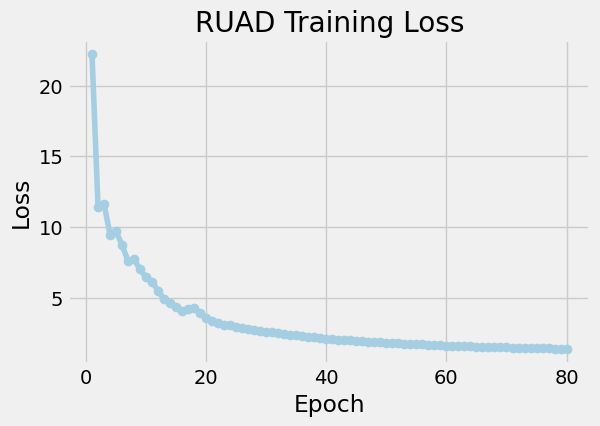

In [44]:
selector = RUAD_AUUC_Selector(hidden_dim=128, epochs=80, lr=1e-3, top_k=50)
X_selected = selector.fit_transform(X_train, treatment_train, y_train, X_val, treatment_val, y_val)

In [45]:
print('Число отобранных признако:', len(selector.selected_features_))

Число отобранных признако: 50


In [46]:
selected_features_v5 = X_selected.columns.tolist()

In [47]:
model_t_v5, model_c_v5, uplift_pred_train_v5, auuc_train_v5, study = train_tlearner(BASE_MODEL, X_train, treatment_train, y_train, 
                                                                             X_val, treatment_val, y_val, 
                                                                             selected_features_v5)

[I 2026-03-24 00:44:26,502] A new study created in memory with name: no-name-87945aa8-5d04-4a76-84b2-c278bc0fb30e
[I 2026-03-24 00:45:25,117] Trial 12 finished with value: 0.5092165578258233 and parameters: {'depth_c': 4, 'learning_rate_c': 0.014035006682887898, 'iterations_c': 416, 'l2_leaf_reg_c': 7.117884336925313, 'bagging_temperature_c': 7.207340837152676, 'random_strength_c': 5.345096663177019, 'min_data_in_leaf_c': 75, 'depth_t': 6, 'learning_rate_t': 0.10417990881912509, 'iterations_t': 378, 'l2_leaf_reg_t': 4.010595646578735, 'bagging_temperature_t': 5.413254560770887, 'random_strength_t': 7.043830458153875, 'min_data_in_leaf_t': 59}. Best is trial 12 with value: 0.5092165578258233.


AUUC: 0.5092165578258233


[I 2026-03-24 00:45:45,920] Trial 6 finished with value: 0.5962841751026436 and parameters: {'depth_c': 7, 'learning_rate_c': 0.17935967702723582, 'iterations_c': 616, 'l2_leaf_reg_c': 17.774681170946003, 'bagging_temperature_c': 6.773796877346745, 'random_strength_c': 8.978445602629801, 'min_data_in_leaf_c': 25, 'depth_t': 6, 'learning_rate_t': 0.06517473279149258, 'iterations_t': 404, 'l2_leaf_reg_t': 14.197041234315549, 'bagging_temperature_t': 0.3605147377081497, 'random_strength_t': 6.796960114701948, 'min_data_in_leaf_t': 65}. Best is trial 6 with value: 0.5962841751026436.


AUUC: 0.5962841751026436


[I 2026-03-24 00:46:36,898] Trial 0 finished with value: 0.5214203773789914 and parameters: {'depth_c': 4, 'learning_rate_c': 0.050614015348518705, 'iterations_c': 1247, 'l2_leaf_reg_c': 8.336888675928394, 'bagging_temperature_c': 2.65739384899915, 'random_strength_c': 8.07444889095416, 'min_data_in_leaf_c': 80, 'depth_t': 5, 'learning_rate_t': 0.051817133644868486, 'iterations_t': 777, 'l2_leaf_reg_t': 2.4524834324333553, 'bagging_temperature_t': 7.57087073267373, 'random_strength_t': 7.654995187908009, 'min_data_in_leaf_t': 4}. Best is trial 6 with value: 0.5962841751026436.


...

AUUC: 0.4766076907098463


[I 2026-03-24 00:55:58,589] Trial 48 finished with value: 0.5319629912615629 and parameters: {'depth_c': 6, 'learning_rate_c': 0.20151817542205788, 'iterations_c': 938, 'l2_leaf_reg_c': 10.952529724325991, 'bagging_temperature_c': 6.385854360300599, 'random_strength_c': 7.405391563381226, 'min_data_in_leaf_c': 64, 'depth_t': 5, 'learning_rate_t': 0.10528529239878705, 'iterations_t': 1354, 'l2_leaf_reg_t': 15.930400514937654, 'bagging_temperature_t': 1.193900417369848, 'random_strength_t': 8.422389649078546, 'min_data_in_leaf_t': 84}. Best is trial 37 with value: 0.7045323016060281.


AUUC: 0.5319629912615629


[I 2026-03-24 00:56:01,462] Trial 49 finished with value: 0.45058182527431845 and parameters: {'depth_c': 6, 'learning_rate_c': 0.19840810971124864, 'iterations_c': 679, 'l2_leaf_reg_c': 11.058858354448152, 'bagging_temperature_c': 0.9672070134852244, 'random_strength_c': 7.05105384386419, 'min_data_in_leaf_c': 65, 'depth_t': 5, 'learning_rate_t': 0.10371570532766065, 'iterations_t': 1499, 'l2_leaf_reg_t': 15.86098985084899, 'bagging_temperature_t': 1.101521742528033, 'random_strength_t': 8.175540318384442, 'min_data_in_leaf_t': 85}. Best is trial 37 with value: 0.7045323016060281.


AUUC: 0.45058182527431845
AUUC: 7.406131175331817


In [48]:
uplift_pred_test_v5, auuc_test_v5 = get_uplift(model_t_v5, model_c_v5, X_test, treatment_test, y_test, selected_features_v5)

AUUC: 0.6049085163796508


### Multihead Causal Distilling Weighting Is All You Need for Uplift Modeling

In [49]:
class CausalFeatureSelector(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.mask = nn.Parameter(torch.ones(input_dim))

    def forward(self, x):

        mask = torch.sigmoid(self.mask)

        return x * mask

class MCDWModel(nn.Module):

    def __init__(self, input_dim, hidden=128, heads=5):

        super().__init__()

        self.selector = CausalFeatureSelector(input_dim)

        self.backbone = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU()
        )

        self.heads = nn.ModuleList([
            nn.Linear(hidden, 1) for _ in range(heads)
        ])

    def forward(self, x):

        x = self.selector(x)

        h = self.backbone(x)

        preds = torch.cat([head(h) for head in self.heads], dim=1)

        return preds

class MCDWFeatureSelector:

    def __init__(
        self,
        hidden=128,
        heads=5,
        epochs=50,
        lr=1e-3,
        lambda_l1=1e-3,
        device='cpu'
    ):

        self.hidden = hidden
        self.heads = heads
        self.epochs = epochs
        self.lr = lr
        self.lambda_l1 = lambda_l1
        self.device = device


    def fit(self, X, t, y):

        if isinstance(X, pd.DataFrame):

            self.feature_names = X.columns
            X = X.values

        else:

            self.feature_names = np.arange(X.shape[1])

        X_tensor = torch.tensor(X, dtype=torch.float32).to(self.device)
        y_tensor = torch.tensor(y, dtype=torch.float32).to(self.device)
        t_tensor = torch.tensor(t, dtype=torch.float32).to(self.device)

        input_dim = X.shape[1]

        self.model = MCDWModel(input_dim, self.hidden, self.heads).to(self.device)

        optimizer = torch.optim.Adam(self.model.parameters(), lr=self.lr)

        losses = []

        for epoch in range(self.epochs):

            preds = self.model(X_tensor)

            target = y_tensor * (2 * t_tensor - 1)

            mse = ((preds - target.unsqueeze(1)) ** 2).mean()

            mask = torch.sigmoid(self.model.selector.mask)

            l1 = mask.abs().mean()

            loss = mse + self.lambda_l1 * l1

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            losses.append(loss.item())

            clear_output(wait=True)
            plt.figure(figsize=(6,4))
            plt.plot(range(1, len(losses)+1), losses, marker='o')
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            plt.title('MCDW Training Loss')
            plt.grid(True)
            plt.show()

        mask_values = torch.sigmoid(self.model.selector.mask).detach().cpu().numpy()

        self.importance_ = mask_values

        return self


    def get_feature_importance(self):
        
        return pd.Series(self.importance_, index=self.feature_names).sort_values(ascending=False)


    def select_top_k(self, k):

        imp = self.get_feature_importance()
        return imp.head(k).index.tolist()


    def transform(self, X, k):

        features = self.select_top_k(k)

        if isinstance(X, pd.DataFrame):
            return X[features]

        else:
            idx = [np.where(self.feature_names == f)[0][0] for f in features]

            return X[:, idx]

In [50]:
selector = MCDWFeatureSelector(
    hidden=256,
    heads=5,
    epochs=30,
    lr=1e-3
)


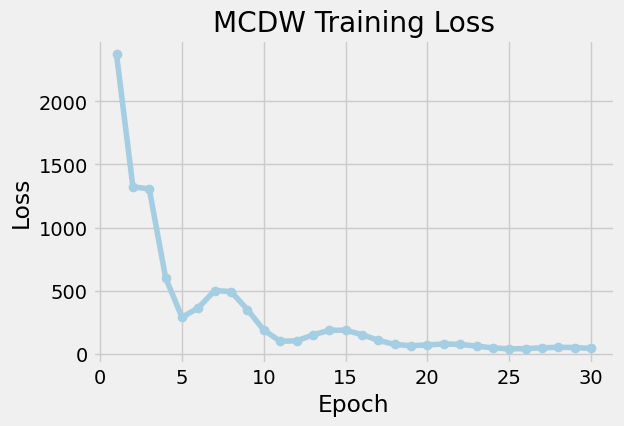

In [51]:
selector.fit(X_train, treatment_train, y_train)

In [52]:
importance = selector.get_feature_importance()

In [53]:
top_50_features = selector.select_top_k(50)

In [54]:
top_30_features = selector.select_top_k(30)

In [55]:
top_80_features = selector.select_top_k(80)

In [56]:
top_50_features

['k_var_count_per_cheque_15d_g34',
 'sale_count_6m_g25',
 'k_var_cheque_category_width_15d',
 'k_var_sku_price_6m_g24',
 'cheque_count_6m_g57',
 'k_var_count_per_cheque_1m_g44',
 'cheque_count_12m_g46',
 'sale_count_6m_g24',
 'k_var_cheque_group_width_15d',
 'cheque_count_3m_g45',
 'sale_count_12m_g49',
 'k_var_disc_share_3m_g48',
 'sale_count_3m_g24',
 'stdev_discount_depth_15d',
 'cheque_count_6m_g40',
 'k_var_count_per_cheque_6m_g27',
 'cheque_count_12m_g20',
 'k_var_disc_share_12m_g32',
 'food_share_1m',
 'cheque_count_6m_g52',
 'k_var_count_per_cheque_6m_g44',
 'k_var_sku_price_12m_g32',
 'k_var_sku_price_1m_g54',
 'k_var_count_per_cheque_1m_g27',
 'cheque_count_6m_g46',
 'k_var_sku_price_6m_g42',
 'k_var_count_per_cheque_3m_g44',
 'cheque_count_12m_g25',
 'k_var_sku_price_15d_g34',
 'promo_share_15d',
 'k_var_sku_price_3m_g46',
 'crazy_purchases_goods_count_6m',
 'crazy_purchases_goods_count_12m',
 'k_var_sku_price_3m_g40',
 'k_var_count_per_cheque_1m_g24',
 'k_var_sku_price_1m_g

In [57]:
model_t_v6, model_c_v6, uplift_pred_train_v6, auuc_train_v6, study = train_tlearner(BASE_MODEL, X_train, treatment_train, y_train, 
                                                                                    X_val, treatment_val, y_val,
                                                                                    top_30_features)

[I 2026-03-24 00:56:39,783] A new study created in memory with name: no-name-bb11f4f6-7264-4860-a2dd-2cab86ec28bd
[I 2026-03-24 00:57:41,992] Trial 2 finished with value: 0.5865426843481228 and parameters: {'depth_c': 4, 'learning_rate_c': 0.04883249456883097, 'iterations_c': 345, 'l2_leaf_reg_c': 16.7626417704435, 'bagging_temperature_c': 1.0378669674124275, 'random_strength_c': 1.332512025134348, 'min_data_in_leaf_c': 11, 'depth_t': 4, 'learning_rate_t': 0.091591544327091, 'iterations_t': 591, 'l2_leaf_reg_t': 7.704480039261518, 'bagging_temperature_t': 5.273603874706155, 'random_strength_t': 9.108294988891396, 'min_data_in_leaf_t': 57}. Best is trial 2 with value: 0.5865426843481228.


AUUC: 0.5865426843481228


[I 2026-03-24 00:58:16,528] Trial 3 finished with value: 0.49490075801273015 and parameters: {'depth_c': 4, 'learning_rate_c': 0.02820066751515296, 'iterations_c': 1207, 'l2_leaf_reg_c': 2.8449062959573572, 'bagging_temperature_c': 5.8241509352110645, 'random_strength_c': 5.062798983588198, 'min_data_in_leaf_c': 75, 'depth_t': 7, 'learning_rate_t': 0.09130759360435084, 'iterations_t': 531, 'l2_leaf_reg_t': 7.009839169937979, 'bagging_temperature_t': 0.9359853442271426, 'random_strength_t': 9.231513810110833, 'min_data_in_leaf_t': 73}. Best is trial 2 with value: 0.5865426843481228.


AUUC: 0.49490075801273015


[I 2026-03-24 00:58:19,776] Trial 5 finished with value: 0.5570181505383651 and parameters: {'depth_c': 5, 'learning_rate_c': 0.015756477999204436, 'iterations_c': 940, 'l2_leaf_reg_c': 10.491467605492822, 'bagging_temperature_c': 5.979609576725359, 'random_strength_c': 5.8465614377842465, 'min_data_in_leaf_c': 10, 'depth_t': 6, 'learning_rate_t': 0.038516775233367884, 'iterations_t': 663, 'l2_leaf_reg_t': 12.856696385554246, 'bagging_temperature_t': 8.167477085916184, 'random_strength_t': 8.529243710589501, 'min_data_in_leaf_t': 40}. Best is trial 2 with value: 0.5865426843481228.


...

AUUC: 0.5765759262968961


[I 2026-03-24 01:07:54,552] Trial 46 finished with value: 0.6269684278346265 and parameters: {'depth_c': 10, 'learning_rate_c': 0.038725482552595426, 'iterations_c': 1372, 'l2_leaf_reg_c': 8.874220877931847, 'bagging_temperature_c': 4.831102853047705, 'random_strength_c': 1.7883391032782132, 'min_data_in_leaf_c': 19, 'depth_t': 7, 'learning_rate_t': 0.02280663117494196, 'iterations_t': 995, 'l2_leaf_reg_t': 11.592165059751673, 'bagging_temperature_t': 4.376733032009728, 'random_strength_t': 4.296133576474326, 'min_data_in_leaf_t': 87}. Best is trial 8 with value: 0.7663894928993018.


AUUC: 0.6269684278346265


[I 2026-03-24 01:07:57,007] Trial 45 finished with value: 0.5778990512690644 and parameters: {'depth_c': 10, 'learning_rate_c': 0.011734396058961215, 'iterations_c': 1356, 'l2_leaf_reg_c': 8.107435672366563, 'bagging_temperature_c': 4.573277367735811, 'random_strength_c': 1.9345123070105434, 'min_data_in_leaf_c': 85, 'depth_t': 9, 'learning_rate_t': 0.020656291680009275, 'iterations_t': 972, 'l2_leaf_reg_t': 11.512366383897117, 'bagging_temperature_t': 4.548313071669468, 'random_strength_t': 4.534235556324903, 'min_data_in_leaf_t': 82}. Best is trial 8 with value: 0.7663894928993018.


AUUC: 0.5778990512690644
AUUC: 3.7833155830801535


In [58]:
uplift_pred_test_v6, auuc_test_v6 = get_uplift(model_t_v6, model_c_v6, X_test, treatment_test, y_test, top_30_features)

AUUC: 0.5033596127965371


In [59]:
model_t_v7, model_c_v7, uplift_pred_train_v7, auuc_train_v7, study = train_tlearner(BASE_MODEL, X_train, treatment_train, y_train, 
                                                                                    X_val, treatment_val, y_val,
                                                                                    top_50_features)

[I 2026-03-24 01:08:11,088] A new study created in memory with name: no-name-adb2b3c1-54b1-4bda-ab54-70240e26ade7
[I 2026-03-24 01:09:45,433] Trial 1 finished with value: 0.5784644095570936 and parameters: {'depth_c': 5, 'learning_rate_c': 0.09161467665779968, 'iterations_c': 542, 'l2_leaf_reg_c': 5.719745341120834, 'bagging_temperature_c': 7.3825713515193705, 'random_strength_c': 3.7769956791630976, 'min_data_in_leaf_c': 90, 'depth_t': 6, 'learning_rate_t': 0.07042728658215533, 'iterations_t': 571, 'l2_leaf_reg_t': 1.7391550112352054, 'bagging_temperature_t': 5.551816892904739, 'random_strength_t': 2.416684079577319, 'min_data_in_leaf_t': 96}. Best is trial 1 with value: 0.5784644095570936.


AUUC: 0.5784644095570936


[I 2026-03-24 01:09:54,285] Trial 5 finished with value: 0.6584404159651402 and parameters: {'depth_c': 8, 'learning_rate_c': 0.032162127009132895, 'iterations_c': 551, 'l2_leaf_reg_c': 6.859894667536504, 'bagging_temperature_c': 2.4460102926306826, 'random_strength_c': 6.064877799088779, 'min_data_in_leaf_c': 89, 'depth_t': 4, 'learning_rate_t': 0.016044506387354867, 'iterations_t': 595, 'l2_leaf_reg_t': 8.936751635154973, 'bagging_temperature_t': 8.407420662140959, 'random_strength_t': 3.0145673127178716, 'min_data_in_leaf_t': 82}. Best is trial 5 with value: 0.6584404159651402.


AUUC: 0.6584404159651402


[I 2026-03-24 01:09:59,317] Trial 13 finished with value: 0.6170352184759592 and parameters: {'depth_c': 4, 'learning_rate_c': 0.1408132451858878, 'iterations_c': 629, 'l2_leaf_reg_c': 12.572409312628327, 'bagging_temperature_c': 1.0647257501543406, 'random_strength_c': 0.14182647553844907, 'min_data_in_leaf_c': 37, 'depth_t': 4, 'learning_rate_t': 0.06991906899846127, 'iterations_t': 782, 'l2_leaf_reg_t': 16.792220812082654, 'bagging_temperature_t': 0.7631653245102821, 'random_strength_t': 2.56578568800488, 'min_data_in_leaf_t': 23}. Best is trial 5 with value: 0.6584404159651402.


...

AUUC: 0.5720361199928606


[I 2026-03-24 01:25:24,774] Trial 47 finished with value: 0.6931097461132133 and parameters: {'depth_c': 8, 'learning_rate_c': 0.03190765714915761, 'iterations_c': 1434, 'l2_leaf_reg_c': 13.197120021389571, 'bagging_temperature_c': 3.4205875363913343, 'random_strength_c': 4.301198796229745, 'min_data_in_leaf_c': 85, 'depth_t': 8, 'learning_rate_t': 0.014106478082324759, 'iterations_t': 1308, 'l2_leaf_reg_t': 9.237716058140432, 'bagging_temperature_t': 7.787069761240345, 'random_strength_t': 1.6596217264437179, 'min_data_in_leaf_t': 72}. Best is trial 12 with value: 0.7043467503820777.


AUUC: 0.6931097461132133


[I 2026-03-24 01:25:25,837] Trial 49 finished with value: 0.6901851121352642 and parameters: {'depth_c': 8, 'learning_rate_c': 0.03365679356260733, 'iterations_c': 1003, 'l2_leaf_reg_c': 13.060418544334492, 'bagging_temperature_c': 3.396656714480657, 'random_strength_c': 6.215599886094541, 'min_data_in_leaf_c': 54, 'depth_t': 8, 'learning_rate_t': 0.015014139633809372, 'iterations_t': 1346, 'l2_leaf_reg_t': 8.763208590466666, 'bagging_temperature_t': 7.173212912370057, 'random_strength_t': 1.6601439639207927, 'min_data_in_leaf_t': 72}. Best is trial 12 with value: 0.7043467503820777.


AUUC: 0.6901851121352642
AUUC: 6.489329917789043


In [60]:
uplift_pred_test_v7, auuc_test_v7 = get_uplift(model_t_v7, model_c_v7, X_test, treatment_test, y_test, top_50_features)

AUUC: 0.5207005561097675


In [61]:
# 128 hidden_dim - 0.5173856389513593 test

In [62]:
model_t_v8, model_c_v8, uplift_pred_train_v8, auuc_train_v8, study = train_tlearner(BASE_MODEL, X_train, treatment_train, y_train, 
                                                                                    X_val, treatment_val, y_val,
                                                                                    top_80_features)

[I 2026-03-24 01:25:46,397] A new study created in memory with name: no-name-62999cfb-196f-4284-99f4-0786103a5788
[I 2026-03-24 01:27:17,124] Trial 9 finished with value: 0.7789138844061197 and parameters: {'depth_c': 4, 'learning_rate_c': 0.05192892967615442, 'iterations_c': 323, 'l2_leaf_reg_c': 19.00624433010454, 'bagging_temperature_c': 3.79001013950937, 'random_strength_c': 3.4049773509537107, 'min_data_in_leaf_c': 45, 'depth_t': 5, 'learning_rate_t': 0.0349523112195651, 'iterations_t': 538, 'l2_leaf_reg_t': 10.11216496085913, 'bagging_temperature_t': 1.327956607645726, 'random_strength_t': 6.079089588207069, 'min_data_in_leaf_t': 98}. Best is trial 9 with value: 0.7789138844061197.


AUUC: 0.7789138844061197


[I 2026-03-24 01:28:29,136] Trial 2 finished with value: 0.5400562344317409 and parameters: {'depth_c': 5, 'learning_rate_c': 0.04085703740069692, 'iterations_c': 621, 'l2_leaf_reg_c': 19.989702446974015, 'bagging_temperature_c': 8.642202513446795, 'random_strength_c': 5.867380832539835, 'min_data_in_leaf_c': 95, 'depth_t': 6, 'learning_rate_t': 0.02420742117509665, 'iterations_t': 831, 'l2_leaf_reg_t': 3.670826067145275, 'bagging_temperature_t': 9.676541283615974, 'random_strength_t': 6.401312748753365, 'min_data_in_leaf_t': 78}. Best is trial 9 with value: 0.7789138844061197.


AUUC: 0.5400562344317409


[I 2026-03-24 01:28:42,007] Trial 1 finished with value: 0.5572695887766812 and parameters: {'depth_c': 6, 'learning_rate_c': 0.02608470626775737, 'iterations_c': 670, 'l2_leaf_reg_c': 1.0498519178869752, 'bagging_temperature_c': 4.7169080391383345, 'random_strength_c': 6.357681458807534, 'min_data_in_leaf_c': 22, 'depth_t': 6, 'learning_rate_t': 0.0633943964696706, 'iterations_t': 866, 'l2_leaf_reg_t': 1.6243174049509082, 'bagging_temperature_t': 5.6526286326259285, 'random_strength_t': 4.191588959698507, 'min_data_in_leaf_t': 70}. Best is trial 9 with value: 0.7789138844061197.


...

AUUC: 0.4549462769868891


[I 2026-03-24 01:39:02,591] Trial 48 finished with value: 0.5409995561735268 and parameters: {'depth_c': 6, 'learning_rate_c': 0.04176948529765448, 'iterations_c': 976, 'l2_leaf_reg_c': 13.467216772147937, 'bagging_temperature_c': 3.562180302724093, 'random_strength_c': 5.325287311429936, 'min_data_in_leaf_c': 12, 'depth_t': 6, 'learning_rate_t': 0.01465011336234242, 'iterations_t': 966, 'l2_leaf_reg_t': 3.4241121683649705, 'bagging_temperature_t': 1.8739355836817255, 'random_strength_t': 7.411474067673247, 'min_data_in_leaf_t': 86}. Best is trial 9 with value: 0.7789138844061197.


AUUC: 0.5409995561735268


[I 2026-03-24 01:39:05,500] Trial 47 finished with value: 0.5513600214622986 and parameters: {'depth_c': 9, 'learning_rate_c': 0.043748650300677594, 'iterations_c': 1003, 'l2_leaf_reg_c': 7.436809980936891, 'bagging_temperature_c': 6.8518200062312715, 'random_strength_c': 6.620504128433752, 'min_data_in_leaf_c': 98, 'depth_t': 6, 'learning_rate_t': 0.01611152105280907, 'iterations_t': 807, 'l2_leaf_reg_t': 14.427984507715255, 'bagging_temperature_t': 1.772654668461981, 'random_strength_t': 0.0366616015600949, 'min_data_in_leaf_t': 82}. Best is trial 9 with value: 0.7789138844061197.


AUUC: 0.5513600214622986
AUUC: 2.0894391359267472


In [63]:
uplift_pred_test_v8, auuc_test_v8 = get_uplift(model_t_v8, model_c_v8, X_test, treatment_test, y_test, top_80_features)

AUUC: 0.6975662133206657


### Вывод

|Статья |Число признаков| AUUC train |AUUC test |
|-------|-----------|----------|-------|
Customer feature selection from high‐dimensional bank direct marketing data for uplift modeling| 48 |  6.72| 0.74 |
Doubly Robust Adaptive LASSO for Effect| 184 |  6.74| 0.49|
A Non-parametric Bayesian Approach for Uplift Discretization and Feature Selection| 12 |  7.03| 0.81|
A Non-parametric Bayesian Approach for Uplift Discretization and Feature Selection| 50 |  5.97| 0.46|
Robustness-enhanced Uplift Modeling with Adversarial Feature Desensitization| 50 |  2.6| 0.50|
Multihead Causal Distilling Weighting Is All You Need for Uplift Modeling| 30 | 6.70| 0.57|
Multihead Causal Distilling Weighting Is All You Need for Uplift Modeling| 50 | 6.77| 0.41|
Multihead Causal Distilling Weighting Is All You Need for Uplift Modeling| 80 | 10.49| 0.50|

Наилучший результат показал эксперимент из статьи A Non-parametric Bayesian Approach for Uplift Discretization and Feature Selection с 12 признаками    

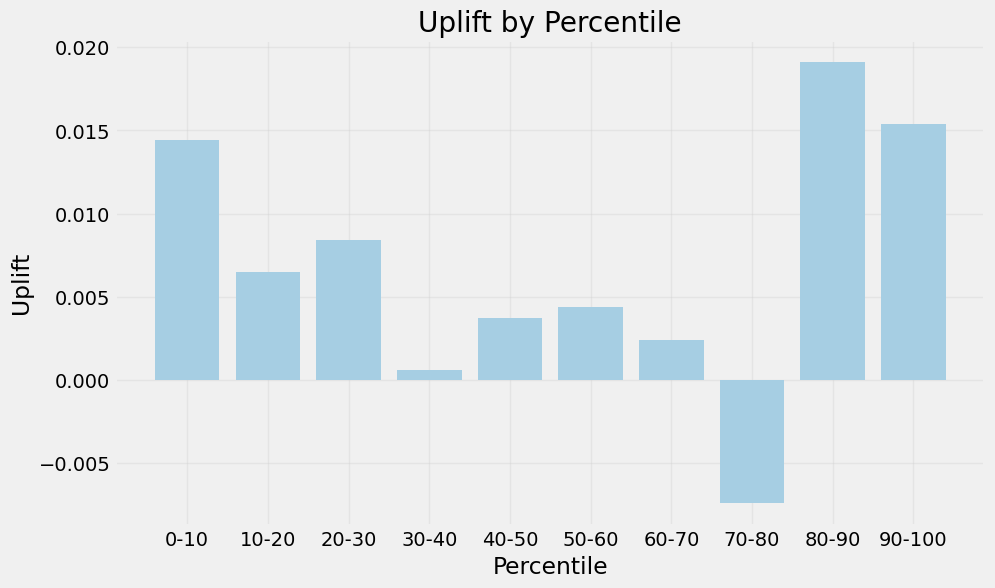

In [64]:
import matplotlib.pyplot as plt
from sklift.metrics import uplift_by_percentile

result = uplift_by_percentile(
    y_test, uplift_pred_test_v1, treatment_test, 
    strategy='overall', bins=10
)

# Строим график
plt.figure(figsize=(10, 6))
plt.bar(range(len(result)), result['uplift'])
plt.xlabel('Percentile')
plt.ylabel('Uplift')
plt.title('Uplift by Percentile')
plt.xticks(range(len(result)), result.index)
plt.grid(True, alpha=0.3)
plt.show()

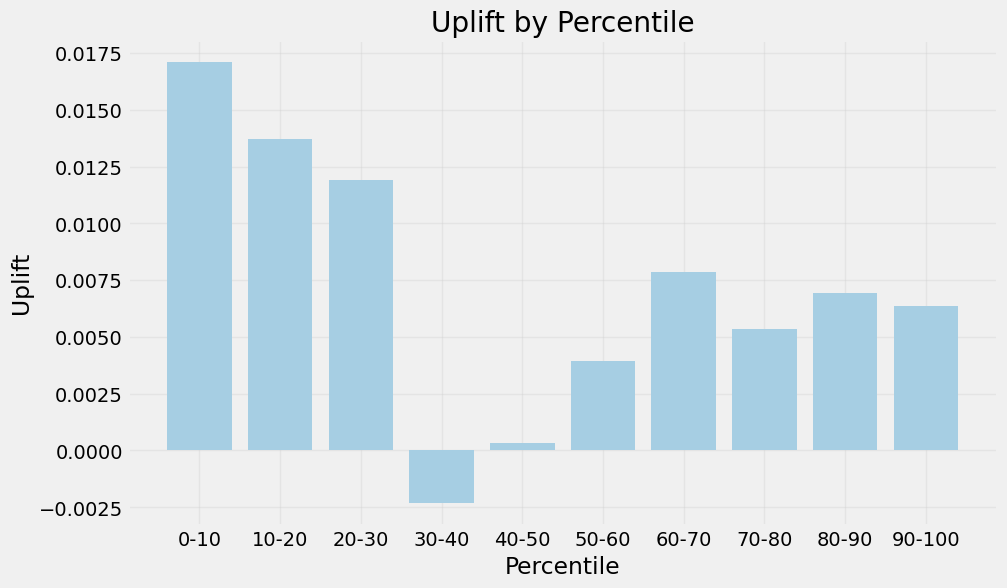

In [65]:
import matplotlib.pyplot as plt
from sklift.metrics import uplift_by_percentile

result = uplift_by_percentile(
    y_test, uplift_pred_test_v2, treatment_test, 
    strategy='overall', bins=10
)

# Строим график
plt.figure(figsize=(10, 6))
plt.bar(range(len(result)), result['uplift'])
plt.xlabel('Percentile')
plt.ylabel('Uplift')
plt.title('Uplift by Percentile')
plt.xticks(range(len(result)), result.index)
plt.grid(True, alpha=0.3)
plt.show()

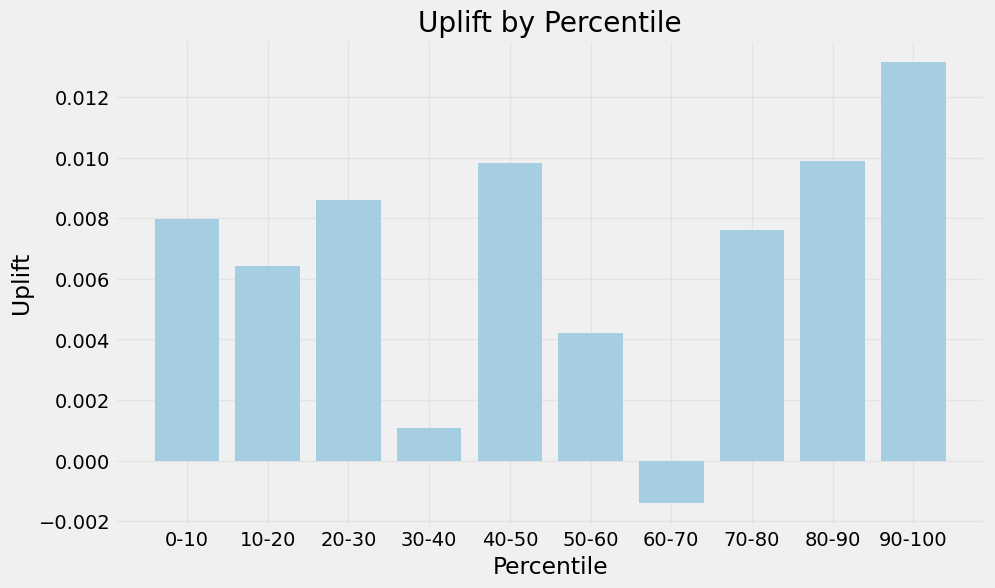

In [66]:
import matplotlib.pyplot as plt
from sklift.metrics import uplift_by_percentile

result = uplift_by_percentile(
    y_test, uplift_pred_test_v3, treatment_test, 
    strategy='overall', bins=10
)

# Строим график
plt.figure(figsize=(10, 6))
plt.bar(range(len(result)), result['uplift'])
plt.xlabel('Percentile')
plt.ylabel('Uplift')
plt.title('Uplift by Percentile')
plt.xticks(range(len(result)), result.index)
plt.grid(True, alpha=0.3)
plt.show()

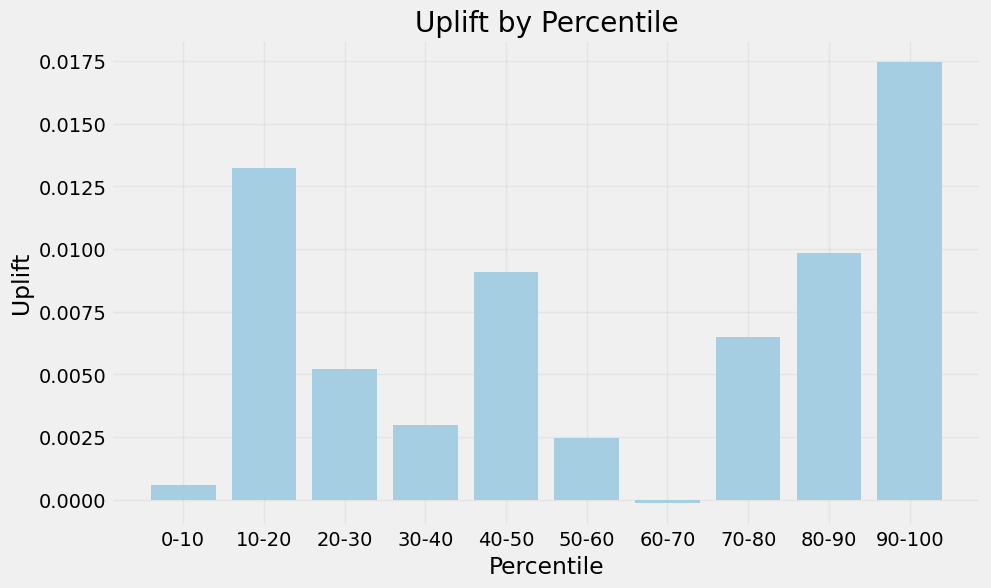

In [67]:
import matplotlib.pyplot as plt
from sklift.metrics import uplift_by_percentile

result = uplift_by_percentile(
    y_test, uplift_pred_test_v4, treatment_test, 
    strategy='overall', bins=10
)

# Строим график
plt.figure(figsize=(10, 6))
plt.bar(range(len(result)), result['uplift'])
plt.xlabel('Percentile')
plt.ylabel('Uplift')
plt.title('Uplift by Percentile')
plt.xticks(range(len(result)), result.index)
plt.grid(True, alpha=0.3)
plt.show()

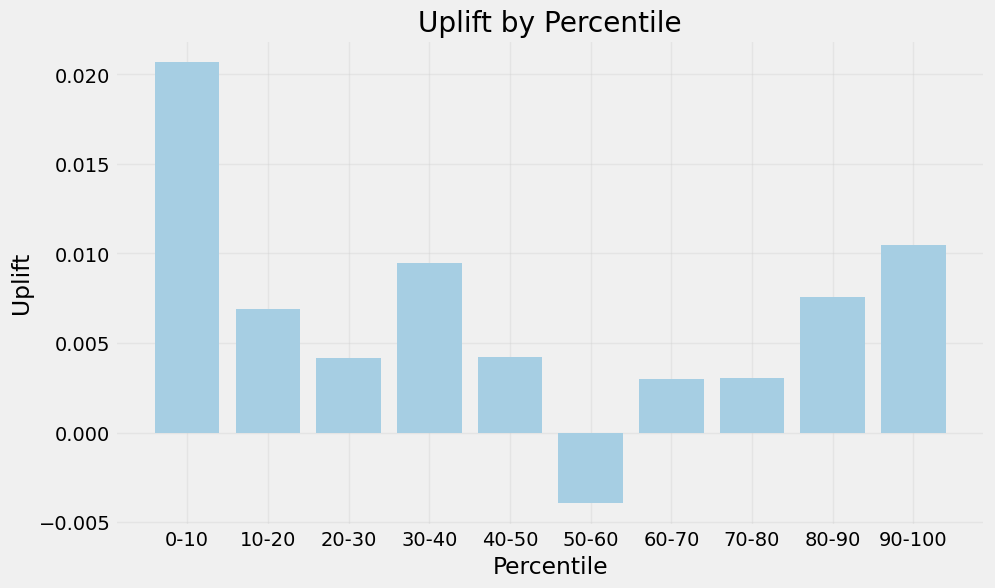

In [68]:
import matplotlib.pyplot as plt
from sklift.metrics import uplift_by_percentile

result = uplift_by_percentile(
    y_test, uplift_pred_test_v5, treatment_test, 
    strategy='overall', bins=10
)

# Строим график
plt.figure(figsize=(10, 6))
plt.bar(range(len(result)), result['uplift'])
plt.xlabel('Percentile')
plt.ylabel('Uplift')
plt.title('Uplift by Percentile')
plt.xticks(range(len(result)), result.index)
plt.grid(True, alpha=0.3)
plt.show()

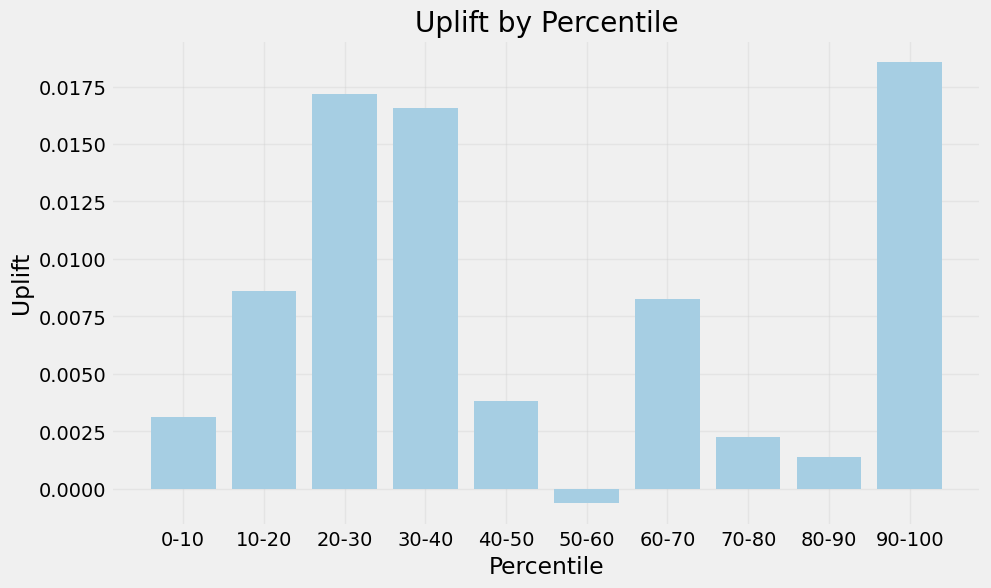

In [69]:
import matplotlib.pyplot as plt
from sklift.metrics import uplift_by_percentile

result = uplift_by_percentile(
    y_test, uplift_pred_test_v6, treatment_test, 
    strategy='overall', bins=10
)

# Строим график
plt.figure(figsize=(10, 6))
plt.bar(range(len(result)), result['uplift'])
plt.xlabel('Percentile')
plt.ylabel('Uplift')
plt.title('Uplift by Percentile')
plt.xticks(range(len(result)), result.index)
plt.grid(True, alpha=0.3)
plt.show()

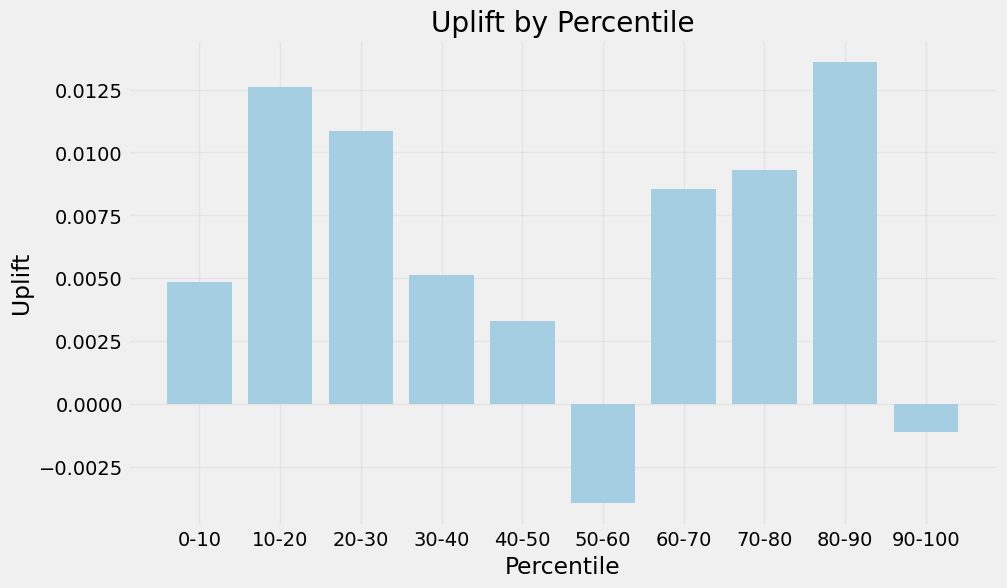

In [70]:
import matplotlib.pyplot as plt
from sklift.metrics import uplift_by_percentile

result = uplift_by_percentile(
    y_test, uplift_pred_test_v7, treatment_test, 
    strategy='overall', bins=10
)

# Строим график
plt.figure(figsize=(10, 6))
plt.bar(range(len(result)), result['uplift'])
plt.xlabel('Percentile')
plt.ylabel('Uplift')
plt.title('Uplift by Percentile')
plt.xticks(range(len(result)), result.index)
plt.grid(True, alpha=0.3)
plt.show()

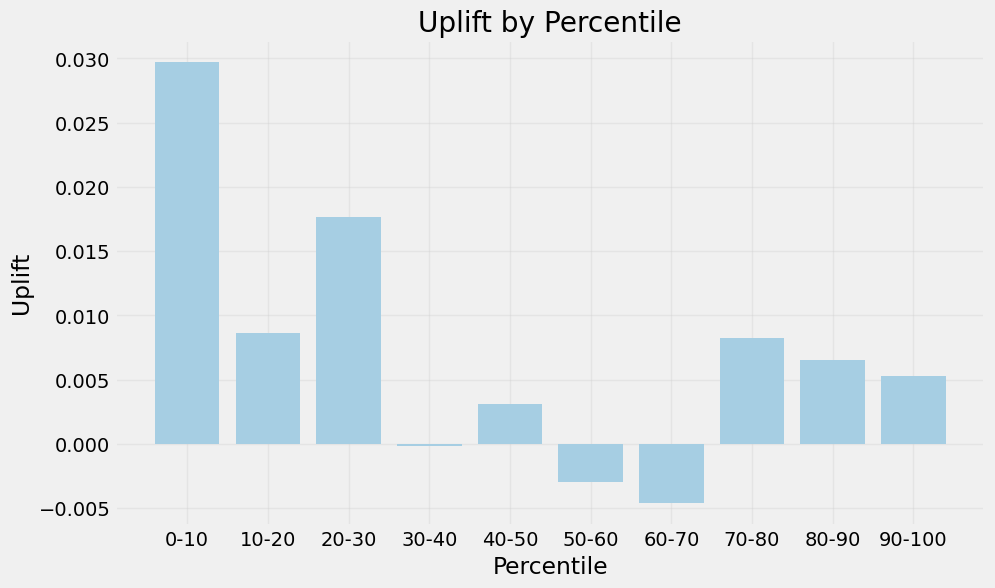

In [71]:
import matplotlib.pyplot as plt
from sklift.metrics import uplift_by_percentile

result = uplift_by_percentile(
    y_test, uplift_pred_test_v8, treatment_test, 
    strategy='overall', bins=10
)

# Строим график
plt.figure(figsize=(10, 6))
plt.bar(range(len(result)), result['uplift'])
plt.xlabel('Percentile')
plt.ylabel('Uplift')
plt.title('Uplift by Percentile')
plt.xticks(range(len(result)), result.index)
plt.grid(True, alpha=0.3)
plt.show()